In [3]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
df = pd.read_csv('./ibtracs.since1980.list.v04r01.csv', skiprows=[1], low_memory=False)
df['WMO_WIND'] = pd.to_numeric(df['WMO_WIND'], errors='coerce')
df['USA_WIND'] = pd.to_numeric(df['USA_WIND'], errors='coerce')
df['SEASON'] = pd.to_numeric(df['SEASON'], errors='coerce')

df['WIND'] = df['WMO_WIND'].fillna(df['USA_WIND'])

In [32]:
hurr = df[df['WIND'] >= 64]

peak = hurr.groupby('SID').agg(
    NAME = ('NAME', 'first'),
    BASIN = ('BASIN', 'first'),
    SEASON = ('SEASON', 'first'),
    WIND = ('WIND', 'max')
).reset_index()

In [72]:
basins = ['WP', 'SI', 'EP', 'SP', 'NI']
basin_names = ['Western Pacific', 'South Indian', 'Eastern Pacific', 'South Pacific', 'North Indian']
results = {}

for basin in basins:
    currentDict = {}
    currentDf = peak[peak['BASIN'] == basin]

    numStorms = len(currentDf)
    numYears = currentDf['SEASON'].max() - currentDf['SEASON'].min() + 1
    currentDict['lambda'] = numStorms/numYears

    logWind = np.log(currentDf['WIND'])
    currentDict['mu'] = logWind.mean()
    currentDict['sigma'] = logWind.std()

    results[basin] = currentDict

In [73]:
num_simulations = 10000
simulated_losses = {}

for basin in basins:
    curLambda = results[basin]['lambda']
    curMu = results[basin]['mu']
    curSigma = results[basin]['sigma']

    annualTotals = []
    for year in range(num_simulations):
        stormCount = np.random.poisson(curLambda)
        intensitySum = 0
        for storm in range(stormCount):
            intensitySum += np.random.lognormal(curMu, curSigma)
        annualTotals.append(intensitySum)

    simulated_losses[basin] = annualTotals

In [77]:
lossResults = {}
for basin in basins:
    losses = {}
    lossArray = np.array(simulated_losses[basin])
    losses['AAL'] = lossArray.mean()
    losses['PML_100'] = np.percentile(lossArray, 99)
    losses['PML_250'] = np.percentile(lossArray, 99.6)
    lossResults[basin] = losses

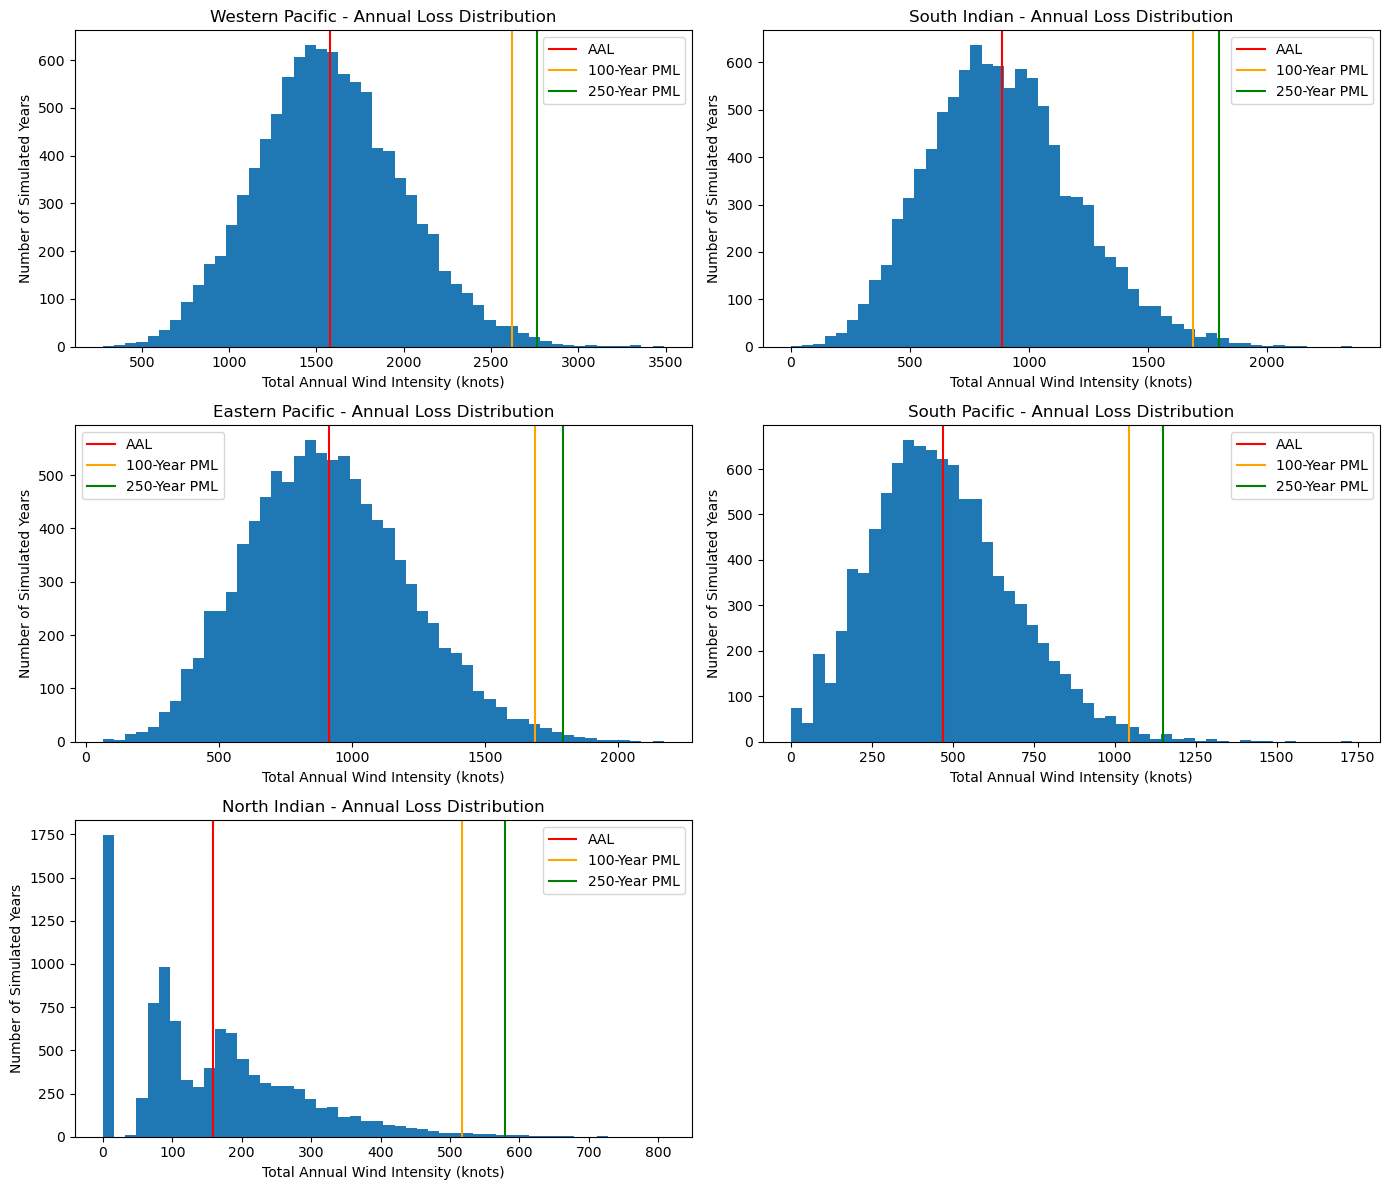

In [79]:
fig, axes = plt.subplots(3, 2, figsize=(14,12), tight_layout=True)
axesList = axes.flatten()

for index, basin in enumerate(basins):
    currAx = axesList[index]

    currAx.set_title(f'{basin_names[index]} - Annual Loss Distribution')
    currAx.set_xlabel('Total Annual Wind Intensity (knots)')
    currAx.set_ylabel('Number of Simulated Years')
    
    currAx.hist(simulated_losses[basin], bins=50)
    currAx.axvline(x=lossResults[basin]['AAL'], color='red', label='AAL')
    currAx.axvline(x=lossResults[basin]['PML_100'], color='orange', label='100-Year PML')
    currAx.axvline(x=lossResults[basin]['PML_250'], color='green', label='250-Year PML')
    currAx.legend()

axesList[5].set_visible(False)

plt.show(fig)